In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Simulated data with labels - for XGBoost (supervised)
features = pd.read_csv("../data/features_with_rules.csv")

In [2]:


# Real YouTube data - for Isolation Forest (unsupervised)
yt_df = pd.read_csv("/Users/shamilikolli/Downloads/videoStatististicsALL_from21_anonymized.csv", sep=";")

In [37]:
print(yt_df.columns.to_list()) # Remove leading/trailing whitespace from column names

['Unnamed: 0', 'video_id', 'created_at', 'comments', 'dislikes', 'likes', 'views', 'like_view_ratio', 'comment_view_ratio', 'dislike_view_ratio']


In [16]:
yt_df.tail()

,Unnamed: 0,video_id,created_at,comments,dislikes,likes,views,like_view_ratio,comment_view_ratio,dislike_view_ratio
45593750,45593750,370132,2022-04-14 15:01:02,6.0,0.0,37.0,1004,0.036816,0.005970,0.0
45593751,45593751,370132,2022-04-14 16:01:05,6.0,0.0,38.0,1005,0.037773,0.005964,0.0
45593752,45593752,370132,2022-04-14 17:01:04,6.0,0.0,38.0,1011,0.037549,0.005929,0.0
45593753,45593753,370132,2022-04-14 18:01:03,6.0,0.0,38.0,1018,0.037291,0.005888,0.0
45593754,45593754,370132,2022-04-14 19:01:04,6.0,0.0,38.0,1018,0.037291,0.005888,0.0


In [3]:
yt_df["created_at"] = pd.to_datetime(yt_df["created_at"])

print(f"Full dataset rows    : {len(yt_df):,}")
print(f"Unique videos        : {yt_df['video_id'].nunique():,}")
print(f"Date range           : {yt_df['created_at'].min()} → {yt_df['created_at'].max()}")
print(f"Avg rows per video   : {len(yt_df)/yt_df['video_id'].nunique():.1f}")
print(f"\nMemory usage: {yt_df.memory_usage(deep=True).sum()/1024/1024:.1f} MB")

Full dataset rows    : 45,593,755
Unique videos        : 270,133
Date range           : 2021-01-01 00:00:28 → 2022-05-10 11:01:11
Avg rows per video   : 168.8

Memory usage: 2435.0 MB


In [9]:
yt_df['video_id'].nunique()

270133

In [5]:
yt_df["like_view_ratio"] = yt_df["likes"] / (yt_df["views"] + 1)
yt_df["comment_view_ratio"] = yt_df["comments"] / (yt_df["views"] + 1)
yt_df["dislike_view_ratio"] = yt_df["dislikes"] / (yt_df["views"] + 1)



In [7]:
sampled_video_ids = yt_df["video_id"].drop_duplicates().sample(10000, random_state=42)
yt_sample = yt_df[yt_df["video_id"].isin(sampled_video_ids)].copy()

print(f"Sampled videos   : {yt_sample['video_id'].nunique():,}")
print(f"Total rows       : {len(yt_sample):,}")
print(f"Memory usage     : {yt_sample.memory_usage(deep=True).sum()/1024/1024:.1f} MB")
print(f"Date range       : {yt_sample['created_at'].min()} → {yt_sample['created_at'].max()}")

Sampled videos   : 10,000
Total rows       : 1,685,568
Memory usage     : 141.5 MB
Date range       : 2021-01-01 00:00:28 → 2022-05-10 11:01:11


In [ ]:
#Time series feature engineering:
def engineer_video_features(df):
    features = []
    
    for video_id, group in df.groupby("video_id"):
        group = group.sort_values("created_at")

        # Skip videos with less than 2 hours of data
        if len(group) < 2:
            continue
        
        # Hour of day when most activity happened
        peak_hour = group.loc[group["views"].diff().idxmax(), "created_at"].hour
        
        # How fast did likes grow vs views
        view_growth = group["views"].diff().fillna(0)
        like_growth = group["likes"].diff().fillna(0)
        
        # Max single hour spike in likes
        max_like_spike = like_growth.max()
        max_view_spike = view_growth.max()
        
        # Ratio of max spike to average growth
        avg_like_growth = like_growth.mean()
        avg_view_growth = view_growth.mean()
        
        features.append({
            "video_id"              : video_id,
            "total_views"           : group["views"].max(),
            "total_likes"           : group["likes"].max(),
            "total_comments"        : group["comments"].max(),
            "like_view_ratio"       : group["likes"].max() / (group["views"].max() + 1),
            "max_like_spike"        : max_like_spike,
            "max_view_spike"        : max_view_spike,
            "like_spike_ratio"      : max_like_spike / (avg_like_growth + 1),
            "view_spike_ratio"      : max_view_spike / (avg_view_growth + 1),
            "peak_hour"             : peak_hour,
            "hours_tracked"         : len(group),
        })
    
    return pd.DataFrame(features)

video_features = engineer_video_features(yt_sample)


In [21]:
video_features.head()

,video_id,total_views,total_likes,total_comments,like_view_ratio,max_like_spike,max_view_spike,like_spike_ratio,view_spike_ratio,peak_hour,hours_tracked
0,100012,3924,52.0,10.0,0.013248,13.0,414.0,10.184332,18.223718,18,170
1,100087,22384,147.0,257.0,0.006567,13.0,2110.0,7.222222,15.993401,0,170
2,100088,5198,89.0,46.0,0.017119,13.0,988.0,9.364407,32.772683,12,170
3,100106,6094,93.0,6.0,0.015258,18.0,970.0,12.540984,27.419355,19,170
4,100119,34569,304.0,176.0,0.008794,58.0,5882.0,23.309693,29.160421,17,170


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Select features for the model
feature_cols = [
    "like_view_ratio",
    "max_like_spike",
    "max_view_spike", 
    "like_spike_ratio",
    "view_spike_ratio",
    "peak_hour",
    "hours_tracked"
]

X = video_features[feature_cols].fillna(0)

# Scale features - important for Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination = expected % of anomalies in data
# We estimate ~5% of videos have fake engagement
iso_forest = IsolationForest(contamination=0.08, random_state=42)
video_features["anomaly_score"] = iso_forest.fit_predict(X_scaled)
video_features["is_suspicious"] = video_features["anomaly_score"] == -1

print(f"Total videos analysed  : {len(video_features):,}")
print(f"Flagged as suspicious  : {video_features['is_suspicious'].sum():,}")
print(f"Suspicion rate         : {video_features['is_suspicious'].mean():.1%}")

Total videos analysed  : 9,999
Flagged as suspicious  : 800
Suspicion rate         : 8.0%


In [34]:
video_features.to_csv("../data/video_features_contamination_10.csv", index=False)

In [10]:
#Inspect flagged video
suspicious = video_features[video_features["is_suspicious"]==True].sort_values(
    "like_spike_ratio", ascending=False)
suspicious.to_csv("../data/suspicious_videos.csv", index=False)

normal = video_features[video_features["is_suspicious"]==False].sort_values(
    "like_spike_ratio", ascending=False)
normal.to_csv("../data/normal_videos.csv", index=False)

print("=== SUSPICIOUS VIDEOS (top 10 by like spike ratio) ===")
print(suspicious[["video_id","total_views","total_likes",
                   "like_view_ratio","like_spike_ratio",
                   "view_spike_ratio","peak_hour"]].head(10))


=== SUSPICIOUS VIDEOS (top 10 by like spike ratio) ===
      video_id  total_views  total_likes  like_view_ratio  like_spike_ratio  \
7037    293512        26804       8038.0         0.299869        111.758449   
9542    358378        10425        277.0         0.026568         97.360179   
1138    130877        18059       1305.0         0.072259         91.722099   
9611    360235         6577        245.0         0.037245         84.735202   
9631    360699         6988       1350.0         0.193161         79.400444   
1189    132271         9551        763.0         0.079879         79.345692   
9511    357691        10122       1131.0         0.111726         78.187614   
6147    269092        10353        564.0         0.054472         76.295181   
383     110994        30084        306.0         0.010171         73.010526   
1157    131486         3753        260.0         0.069259         71.767810   

      view_spike_ratio  peak_hour  
7037         14.813946         22  
954

In [11]:
def assign_tier(row):
    if not row["is_suspicious"]:
        return "clean"
    elif row["like_spike_ratio"] > 30:
        return "tier1_high_confidence"
    elif row["like_spike_ratio"] > 20:
        return "tier2_human_review"
    elif row["like_spike_ratio"] > 10:
        return "tier3_watchlist"
    else:
        return "tier4_ignore"

video_features["enforcement_tier"] = video_features.apply(assign_tier, axis=1)

print(video_features["enforcement_tier"].value_counts())

# Save everything
video_features.to_csv("../data/video_features_final.csv", index=False)
suspicious = video_features[video_features["is_suspicious"]==True].sort_values(
    "like_spike_ratio", ascending=False)
suspicious.to_csv("../data/suspicious_videos_tiered.csv", index=False)

print("\nFiles saved ✓")

enforcement_tier
clean                    9199
tier4_ignore              280
tier2_human_review        192
tier1_high_confidence     173
tier3_watchlist           155
Name: count, dtype: int64

Files saved ✓


In [12]:
print("\n=== NORMAL VIDEOS (sample) ===")
print(normal[["video_id","total_views","total_likes",
              "like_view_ratio","like_spike_ratio",
              "view_spike_ratio","peak_hour"]].head(10))


=== NORMAL VIDEOS (sample) ===
      video_id  total_views  total_likes  like_view_ratio  like_spike_ratio  \
267     107689        22861        140.0         0.006124         42.073579   
7221    297875         3093         58.0         0.018746         41.141553   
1624    144129        26826        191.0         0.007120         38.323699   
1228    133304         3060        268.0         0.087553         35.416667   
9619    360426         8442        141.0         0.016700         34.596491   
1471    139823        10754        127.0         0.011808         34.475524   
277     108051        16730        252.0         0.015062         34.425000   
9       100271        56547        556.0         0.009832         33.048951   
8070    320437        33609        518.0         0.015412         32.759124   
468     112786        23015        278.0         0.012079         31.931217   

      view_spike_ratio  peak_hour  
267          19.487314         12  
7221         25.644902    

In [13]:
print(f"\nAvg like_spike_ratio - Suspicious : {suspicious['like_spike_ratio'].mean():.1f}")
print(f"Avg like_spike_ratio - Normal     : {normal['like_spike_ratio'].mean():.1f}")


Avg like_spike_ratio - Suspicious : 18.9
Avg like_spike_ratio - Normal     : 3.8


In [14]:
def add_sustainability(df):
    results = []
    
    for video_id, group in df.groupby("video_id"):
        group = group.sort_values("created_at")
        
        if len(group) < 3:
            continue
        
        like_growth = group["likes"].diff().fillna(0)
        
        # Find the hour of maximum spike
        spike_idx = like_growth.idxmax()
        spike_pos = group.index.get_loc(spike_idx)
        
        # Look at what happens AFTER the spike
        # If bot: likes drop back to near zero immediately
        # If viral: likes stay elevated for several hours
        if spike_pos + 3 < len(group):
            after_spike = like_growth.iloc[spike_pos+1 : spike_pos+4].mean()
            spike_value = like_growth.iloc[spike_pos]
            
            # Ratio of post-spike activity to spike itself
            # Low ratio = dropped immediately = bot signature
            sustainability = after_spike / (spike_value + 1)
        else:
            sustainability = 0
            
        results.append({
            "video_id"       : video_id,
            "sustainability" : sustainability
        })
    
    return pd.DataFrame(results)

print("Calculating sustainability... takes about a minute")
sustainability_df = add_sustainability(yt_sample)
video_features = video_features.merge(sustainability_df, on="video_id", how="left")

print(f"Feature added ✓")
print(f"\nSustainability stats:")
print(video_features["sustainability"].describe())

Calculating sustainability... takes about a minute
Feature added ✓

Sustainability stats:
count    9999.000000
mean        0.134525
std         0.216955
min        -0.619048
25%         0.000000
50%         0.000000
75%         0.238492
max         0.952381
Name: sustainability, dtype: float64


In [15]:
print(f"\nSuspicious avg sustainability: {video_features[video_features['is_suspicious']]['sustainability'].mean():.3f}")
print(f"Normal avg sustainability    : {video_features[~video_features['is_suspicious']]['sustainability'].mean():.3f}")


Suspicious avg sustainability: 0.319
Normal avg sustainability    : 0.119


In [16]:
feature_cols = [
    "like_view_ratio",
    "max_like_spike",
    "max_view_spike",
    "like_spike_ratio",
    "view_spike_ratio",
    "peak_hour",
    "hours_tracked",
    "sustainability"
]

X = video_features[feature_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest2 = IsolationForest(contamination=0.05, random_state=42)
video_features["anomaly_score_v2"] = iso_forest2.fit_predict(X_scaled)
video_features["is_suspicious_v2"] = video_features["anomaly_score_v2"] == -1

# Compare v1 vs v2 flagging
both_flagged    = ((video_features["is_suspicious"]) & (video_features["is_suspicious_v2"])).sum()
only_v1_flagged = ((video_features["is_suspicious"]) & (~video_features["is_suspicious_v2"])).sum()
only_v2_flagged = ((~video_features["is_suspicious"]) & (video_features["is_suspicious_v2"])).sum()

print(f"Flagged by both models    : {both_flagged}")
print(f"Dropped by v2 (v1 only)  : {only_v1_flagged}")
print(f"New flags in v2           : {only_v2_flagged}")

Flagged by both models    : 487
Dropped by v2 (v1 only)  : 313
New flags in v2           : 13


In [22]:
yt_sample.head()

,Unnamed: 0,video_id,created_at,comments,dislikes,likes,views,like_view_ratio,comment_view_ratio,dislike_view_ratio,hour
2040,2040,100012,2021-05-31 15:00:13,3.0,0.0,5.0,81,0.060976,0.036585,0.000000,15
2041,2041,100012,2021-05-31 16:00:13,5.0,1.0,18.0,152,0.117647,0.032680,0.006536,16
2042,2042,100012,2021-05-31 17:00:13,5.0,1.0,22.0,184,0.118919,0.027027,0.005405,17
2043,2043,100012,2021-05-31 18:00:14,5.0,2.0,23.0,598,0.038397,0.008347,0.003339,18
2044,2044,100012,2021-05-31 19:00:15,8.0,2.0,24.0,897,0.026726,0.008909,0.002227,19


# ============================================================
# 1. PEAK HOUR CLUSTERING — Bot farms may often spike on schedule
# ============================================================

In [32]:
from sklearn.cluster import DBSCAN
from collections import Counter
import seaborn as sns

In [33]:
def detect_peak_hour_clusters(df, min_cluster_size=5):
    """
    Groups videos by peak_hour. Large clusters at odd hours (3AM, 4AM) 
    suggest coordinated bot activity.
    """
    peak_counts = df['peak_hour'].value_counts()
    
    # Hours with unusually high activity
    mean_peaks = peak_counts.mean()
    std_peaks = peak_counts.std()
    suspicious_hours = peak_counts[peak_counts > mean_peaks + 1.5 * std_peaks].index.tolist()
    
    df['is_suspicious_hour'] = df['peak_hour'].isin(suspicious_hours)
    
    # Size of each peak hour cluster
    hour_cluster_size = df.groupby('peak_hour').size().to_dict()
    df['peak_hour_cluster_size'] = df['peak_hour'].map(hour_cluster_size)
    
    return df, suspicious_hours

video_features, suspicious_hours = detect_peak_hour_clusters(video_features)
print(f"Suspicious peak hours (possible bot schedule): {sorted(suspicious_hours)}")
print(video_features['peak_hour'].value_counts().head(10))

Suspicious peak hours (possible bot schedule): [12]
peak_hour
12    886
21    754
20    686
22    676
11    615
19    585
16    525
0     517
23    502
17    492
Name: count, dtype: int64


# ============================================================
# 2. ENGAGEMENT PATTERN SIMILARITY — Same bot network signature
# ============================================================

# Bot farms often use identical settings across all their videos.
# This creates tight clusters in engagement ratio space.

In [35]:
# Add the missing column first
video_features["comment_view_ratio"] = video_features["total_comments"] / (video_features["total_views"] + 1)


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

def detect_engagement_clusters_v2(df, eps=0.3, min_samples=5):
    """
    Use MORE features and standardize them first.
    Cluster on: like_view_ratio, comment_view_ratio, sustainability, like_spike_ratio
    """
    cluster_features = ['like_view_ratio', 'comment_view_ratio', 'sustainability', 'like_spike_ratio']
    X = df[cluster_features].fillna(0)
    
    # CRITICAL: Standardize so all features contribute equally
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # eps=0.3 in standardized space = ~0.3 standard deviations apart
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    df['engagement_cluster'] = clustering.labels_
    df['in_engagement_cluster'] = df['engagement_cluster'] != -1
    
    # Only count real clusters (not noise)
    cluster_sizes = df[df['engagement_cluster'] != -1].groupby('engagement_cluster').size()
    df['engagement_cluster_size'] = df['engagement_cluster'].map(cluster_sizes).fillna(0)
    
    return df, cluster_sizes

video_features, engagement_clusters = detect_engagement_clusters_v2(video_features)
print(f"Found {len(engagement_clusters)} clusters")
print(f"Cluster sizes:\n{engagement_clusters.sort_values(ascending=False).head(10)}")

Found 9 clusters
Cluster sizes:
engagement_cluster
0    9534
1      13
2       6
7       6
5       6
6       5
3       5
4       4
8       3
dtype: int64


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# ============================================================
# FIXED: Only cluster the SUSPICIOUS subset (real T&S workflow)
# ============================================================

def detect_bot_networks(df, eps=0.5, min_samples=3):
    """
    Cluster ONLY videos already flagged as suspicious.
    Normal videos are left as noise (-1).
    This finds 'families' of abuse within the investigation queue.
    """
    suspicious_mask = df['is_suspicious_v2'] == True
    suspicious_df = df[suspicious_mask].copy()
    
    print(f"Investigation queue size: {len(suspicious_df)} videos")
    
    if len(suspicious_df) < 10:
        print("Too few suspicious videos for meaningful clustering")
        df['bot_network_id'] = -1
        df['in_bot_network'] = False
        df['bot_network_size'] = 0
        return df, pd.Series()
    
    # Features that bot networks share: engagement style + timing + sustainability
    cluster_features = ['like_view_ratio', 'comment_view_ratio', 'sustainability', 'like_spike_ratio', 'peak_hour']
    X = suspicious_df[cluster_features].fillna(0)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # eps=0.5 in standardized space = moderate separation
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    suspicious_df['bot_network_id'] = clustering.labels_
    
    # Merge back to full dataframe
    df['bot_network_id'] = -1
    df.loc[suspicious_df.index, 'bot_network_id'] = suspicious_df['bot_network_id']
    
    df['in_bot_network'] = (df['bot_network_id'] != -1) & (df['is_suspicious_v2'] == True)
    
    # Network sizes (only for suspicious videos in real clusters)
    network_sizes = suspicious_df[suspicious_df['bot_network_id'] != -1].groupby('bot_network_id').size()
    df['bot_network_size'] = df['bot_network_id'].map(network_sizes).fillna(0)
    
    print(f"\nFound {len(network_sizes)} bot networks")
    print(f"Network sizes:\n{network_sizes.sort_values(ascending=False)}")
    print(f"\nVideos in networks: {df['in_bot_network'].sum()}")
    print(f"Solo suspicious videos (no network): {(suspicious_mask & (df['bot_network_id'] == -1)).sum()}")
    
    return df, network_sizes

video_features, bot_networks = detect_bot_networks(video_features)

Investigation queue size: 500 videos

Found 15 bot networks
Network sizes:
bot_network_id
1     85
4     64
6     63
0     14
8     11
10     7
5      6
13     6
2      5
3      4
7      4
14     4
9      3
12     3
11     3
dtype: int64

Videos in networks: 282
Solo suspicious videos (no network): 218


In [50]:
# Always run this after clustering to catch the "one big blob" problem
if video_features['engagement_cluster_size'].max() > len(video_features) * 0.5:
    print("⚠️ WARNING: One cluster contains >50% of videos. DBSCAN eps is too large.")
    print("Reduce eps or add more features.")
else:
    print("✓ Clustering looks healthy.")

⚠️ WARNING: One cluster contains >50% of videos. DBSCAN eps is too large.
Reduce eps or add more features.


# ============================================================
# 3. TEMPORAL CO-SPIKING — Videos spiking together in time
# ============================================================

In [39]:
# We need to go back to yt_sample (time-series data) for this
def detect_cospiking(df_raw, window_hours=2):
    """
    Finds videos that had their max like spike within the same hour window.
    Bot networks often hit multiple videos simultaneously.
    """
    results = []
    
    for video_id, group in df_raw.groupby("video_id"):
        if len(group) < 2:
            continue
            
        group = group.sort_values("created_at")
        like_growth = group["likes"].diff().fillna(0)
        
        # Find the exact timestamp of max spike
        if like_growth.max() > 0:
            spike_idx = like_growth.idxmax()
            spike_time = group.loc[group.index == spike_idx, "created_at"].iloc[0]
            spike_value = like_growth.max()
            
            results.append({
                "video_id": video_id,
                "spike_time": spike_time,
                "spike_hour": spike_time.floor('h'),
                "spike_value": spike_value
            })
    
    spike_df = pd.DataFrame(results)
    
    # Count how many videos spiked in each hour window
    spike_counts = spike_df.groupby('spike_hour').size()
    spike_df['cospike_count'] = spike_df['spike_hour'].map(spike_counts)
    
    # Videos that spiked alongside 5+ others in same hour = coordinated
    spike_df['is_cospike'] = spike_df['cospike_count'] >= 5
    
    return spike_df

print("\nDetecting temporal co-spikes...")
spike_df = detect_cospiking(yt_sample)
print(f"Videos in co-spike windows: {spike_df['is_cospike'].sum()}")

# Merge back to video_features
video_features = video_features.merge(
    spike_df[['video_id', 'cospike_count', 'is_cospike']], 
    on='video_id', 
    how='left'
)
video_features['is_cospike'] = video_features['is_cospike'].fillna(False)
video_features['cospike_count'] = video_features['cospike_count'].fillna(0)


Detecting temporal co-spikes...
Videos in co-spike windows: 307


In [ ]:
# ============================================================
# 4. COORDINATED BOT FARM SCORE — Combine all signals
# ============================================================

In [52]:
def calculate_coordination_score_v2(row):
    score = 0
    
    # Base: Isolation Forest flag
    if row['is_suspicious_v2']:
        score += 2
    
    # Part of a confirmed bot network (multi-video coordination)
    if row['in_bot_network'] and row['bot_network_size'] >= 3:
        score += 3  # Higher weight — this is the strongest signal
    
    # Spiked at a suspicious hour (bot schedule)
    if row.get('is_suspicious_hour', False):
        score += 1.5
    
    # Co-spiked with other videos
    if row.get('is_cospike', False):
        score += 2
    
    # Classic bot signature: low sustainability + high spike
    if row['sustainability'] < 0.1 and row['like_spike_ratio'] > 20:
        score += 1.5
    
    # Solo suspicious but no network — still worth reviewing
    if row['is_suspicious_v2'] and not row['in_bot_network'] and row['like_spike_ratio'] > 15:
        score += 1
    
    return score

video_features['coordination_score'] = video_features.apply(calculate_coordination_score_v2, axis=1)

# Updated tiers
def assign_tier_v3(row):
    if not row['is_suspicious_v2'] and row['coordination_score'] < 2:
        return "clean"
    elif row['in_bot_network'] and row['bot_network_size'] >= 5:
        return "tier1_confirmed_bot_network"  # Auto-action, high confidence
    elif row['in_bot_network'] and row['bot_network_size'] >= 3:
        return "tier2_likely_bot_family"      # Human review + network analysis
    elif row['coordination_score'] >= 4:
        return "tier3_suspicious_solo"        # Watchlist
    elif row['is_suspicious_v2']:
        return "tier4_low_confidence_solo"    # Re-check next cycle
    else:
        return "clean"

video_features['enforcement_tier_v3'] = video_features.apply(assign_tier_v3, axis=1)

print("\n=== NEW TIER DISTRIBUTION (Bot Network Aware) ===")
print(video_features['enforcement_tier_v3'].value_counts())


=== NEW TIER DISTRIBUTION (Bot Network Aware) ===
enforcement_tier_v3
clean                          9496
tier1_confirmed_bot_network     261
tier4_low_confidence_solo       179
tier3_suspicious_solo            42
tier2_likely_bot_family          21
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. UPDATED ENFORCEMENT TIERS — Now includes coordination
# ============================================================

In [41]:
def assign_tier_v2(row):
    if not row['is_suspicious_v2'] and row['coordination_score'] < 2:
        return "clean"
    elif row['coordination_score'] >= 6:
        return "tier1_coordinated_bot_farm"  # Auto-action, high confidence
    elif row['coordination_score'] >= 4:
        return "tier2_likely_coordinated"      # Human review + network analysis
    elif row['coordination_score'] >= 2:
        return "tier3_suspicious_solo"         # Watchlist, re-check next cycle
    else:
        return "tier4_low_confidence"

video_features['enforcement_tier_v2'] = video_features.apply(assign_tier_v2, axis=1)

print("\n=== NEW TIER DISTRIBUTION (with Coordination Detection) ===")
print(video_features['enforcement_tier_v2'].value_counts())


=== NEW TIER DISTRIBUTION (with Coordination Detection) ===
enforcement_tier_v2
tier3_suspicious_solo         9206
tier2_likely_coordinated       727
tier1_coordinated_bot_farm      53
clean                           13
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6. INVESTIGATION DASHBOARD — Top coordinated networks
# ============================================================


In [42]:
print("\n=== TOP COORDINATED BOT FARMS ===")
bot_farms = video_features[
    video_features['enforcement_tier_v2'] == 'tier1_coordinated_bot_farm'
].sort_values('coordination_score', ascending=False)

print(bot_farms[[
    'video_id', 'total_views', 'total_likes', 'like_view_ratio',
    'sustainability', 'peak_hour', 'peak_hour_cluster_size',
    'engagement_cluster_size', 'cospike_count', 'coordination_score'
]].head(15))


=== TOP COORDINATED BOT FARMS ===
      video_id  total_views  total_likes  like_view_ratio  sustainability  \
1413    138340         8957        107.0         0.011945        0.046784   
9357    353456        30784        947.0         0.030762        0.087963   
9358    353459       165978       2678.0         0.016135        0.071625   
2057    155649       282010       3358.0         0.011907        0.008772   
6162    269297         1830         93.0         0.050792        0.000000   
8795    339936       145029       4609.0         0.031780        0.115843   
9684    362209        62290        254.0         0.004078        0.006803   
9438    355627        37081        457.0         0.012324        0.005848   
9582    359520        13072       2299.0         0.175859        0.566766   
821     122232        18858         93.0         0.004931        0.000000   
6788    286594       101458       5186.0         0.051114        0.139405   
8206    324111         4861        186.0 

In [ ]:
# ============================================================
# 7. VISUALIZATION — Coordination patterns
# ============================================================

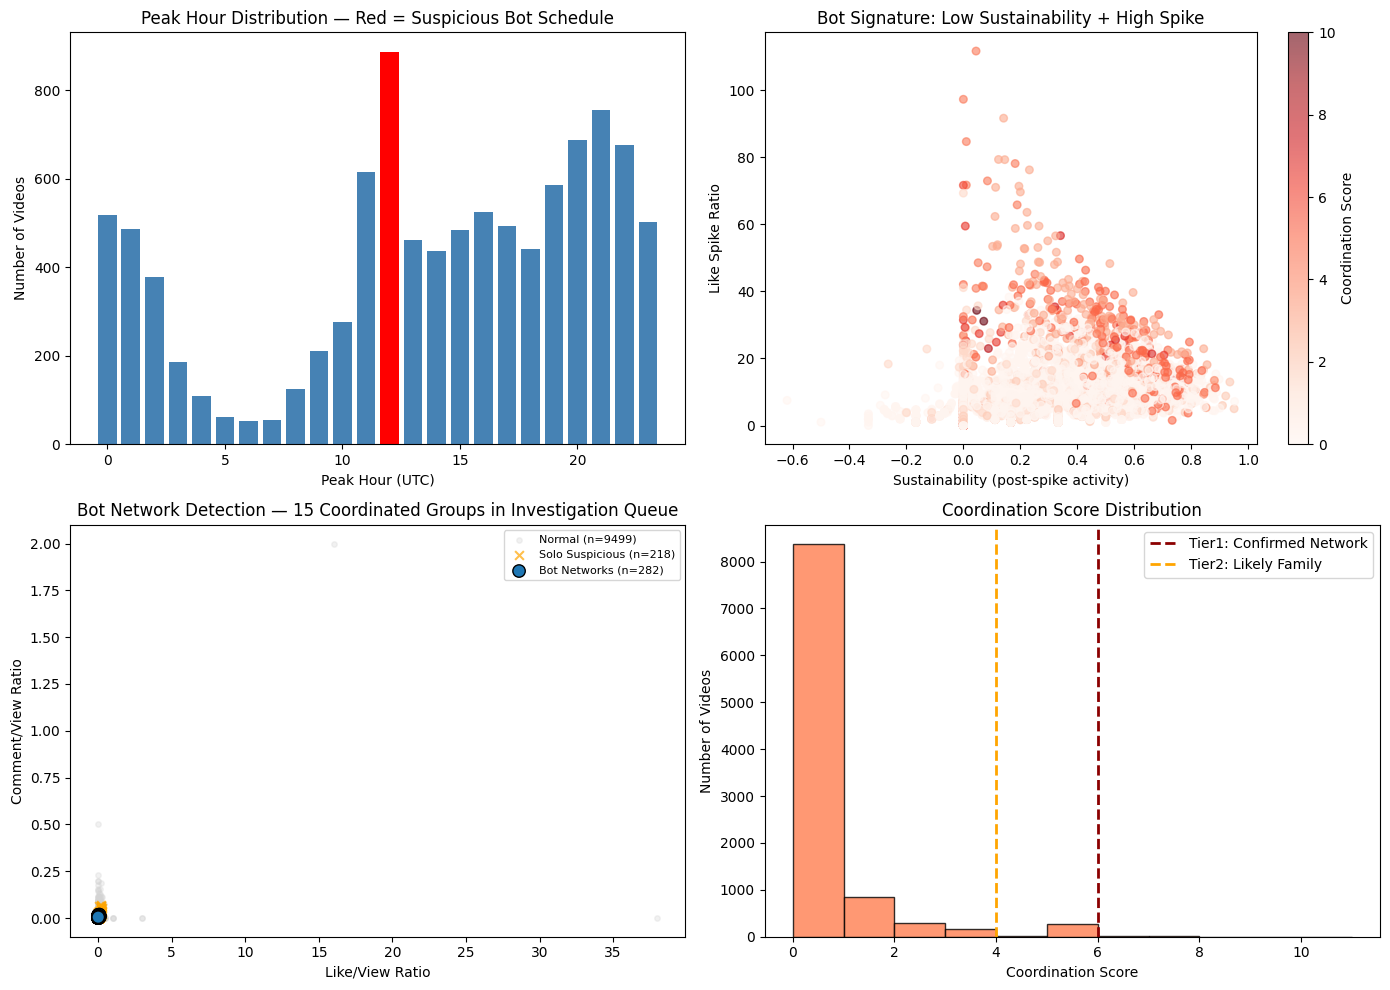

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PLOT 1: Peak Hour Distribution ---
ax1 = axes[0, 0]
hour_counts = video_features['peak_hour'].value_counts().sort_index()
colors = ['red' if h in suspicious_hours else 'steelblue' for h in hour_counts.index]
ax1.bar(hour_counts.index, hour_counts.values, color=colors)
ax1.set_xlabel('Peak Hour (UTC)')
ax1.set_ylabel('Number of Videos')
ax1.set_title('Peak Hour Distribution — Red = Suspicious Bot Schedule')

# --- PLOT 2: Sustainability vs Like Spike Ratio ---
ax2 = axes[0, 1]
scatter = ax2.scatter(
    video_features['sustainability'], 
    video_features['like_spike_ratio'],
    c=video_features['coordination_score'],
    cmap='Reds', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=ax2, label='Coordination Score')
ax2.set_xlabel('Sustainability (post-spike activity)')
ax2.set_ylabel('Like Spike Ratio')
ax2.set_title('Bot Signature: Low Sustainability + High Spike')

# --- PLOT 3: Bot Networks (only suspicious + clustered) ---
ax3 = axes[1, 0]

# Plot all normal videos as light gray
normal = video_features[~video_features['is_suspicious_v2']]
ax3.scatter(normal['like_view_ratio'], normal['comment_view_ratio'], 
            c='lightgray', alpha=0.3, s=15, label=f'Normal (n={len(normal)})')

# Plot suspicious videos NOT in networks as orange
solo_suspicious = video_features[(video_features['is_suspicious_v2']) & (~video_features['in_bot_network'])]
if len(solo_suspicious) > 0:
    ax3.scatter(solo_suspicious['like_view_ratio'], solo_suspicious['comment_view_ratio'],
                c='orange', alpha=0.7, s=40, marker='x', label=f'Solo Suspicious (n={len(solo_suspicious)})')

# Plot bot networks with distinct colors
network_videos = video_features[video_features['in_bot_network']]
if len(network_videos) > 0:
    scatter_net = ax3.scatter(
        network_videos['like_view_ratio'], 
        network_videos['comment_view_ratio'],
        c=network_videos['bot_network_id'], 
        cmap='tab10', s=80, edgecolors='black', linewidth=1,
        label=f'Bot Networks (n={len(network_videos)})', zorder=5
    )
    n_networks = network_videos['bot_network_id'].nunique()
    ax3.set_title(f'Bot Network Detection — {n_networks} Coordinated Groups in Investigation Queue')
else:
    ax3.set_title('Bot Network Detection — No Networks Found')

ax3.set_xlabel('Like/View Ratio')
ax3.set_ylabel('Comment/View Ratio')
ax3.legend(loc='upper right', fontsize=8)

# --- PLOT 4: Coordination Score Distribution ---
ax4 = axes[1, 1]
scores = video_features['coordination_score']
ax4.hist(scores, bins=range(0, int(scores.max()) + 2), color='coral', edgecolor='black', alpha=0.8)

# Threshold lines
if scores.max() >= 6:
    ax4.axvline(x=6, color='darkred', linestyle='--', linewidth=2, label='Tier1: Confirmed Network')
if scores.max() >= 4:
    ax4.axvline(x=4, color='orange', linestyle='--', linewidth=2, label='Tier2: Likely Family')

ax4.set_xlabel('Coordination Score')
ax4.set_ylabel('Number of Videos')
ax4.set_title('Coordination Score Distribution')
ax4.legend()

plt.tight_layout()
plt.show()